In [1]:
pip install qiskit

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install pylatexenc

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [4]:
## Imports
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator
import matplotlib.pyplot as plt
import copy
import random
from joblib import Parallel, delayed
import time
import math
import pylatexenc

🔧 Paramètres de la fenêtre glissante SPATIALE:
  - Taille des blocs: 3 qubits
  - Chevauchement: 0 qubits
  - Seuil de validité: 0.05
  - Max ajustements: 10
🎯 Circuit Cible:


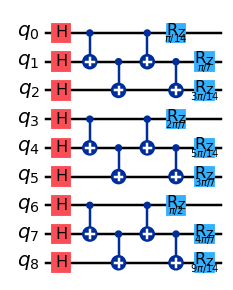


🚀 Démarrage de l'optimisation multi-objectifs avec découpage spatial...
Paramètres: 9 qubits, 18 gènes, 50 individus, 10 générations

Génération 1/10
Front de Pareto: 8 solutions
Fidélité: 0.0032 ± 0.0022
Profondeur: 4.50 ± 0.87
Coût: 25.50 ± 5.85

Génération 2/10
Front de Pareto: 8 solutions
Fidélité: 0.0018 ± 0.0028
Profondeur: 3.62 ± 0.70
Coût: 21.00 ± 3.12

Génération 3/10
Front de Pareto: 7 solutions
Fidélité: 0.0036 ± 0.0042
Profondeur: 3.86 ± 0.83
Coût: 18.86 ± 1.25

Génération 4/10
Front de Pareto: 10 solutions
Fidélité: 0.0061 ± 0.0045
Profondeur: 3.50 ± 0.67
Coût: 19.00 ± 1.73

Génération 5/10
Front de Pareto: 11 solutions
Fidélité: 0.0066 ± 0.0056
Profondeur: 3.27 ± 0.62
Coût: 19.00 ± 1.81

Génération 6/10
Front de Pareto: 7 solutions
Fidélité: 0.0100 ± 0.0045
Profondeur: 3.86 ± 0.83
Coût: 18.86 ± 1.73

Génération 7/10
Front de Pareto: 14 solutions
Fidélité: 0.0088 ± 0.0054
Profondeur: 3.71 ± 0.88
Coût: 18.79 ± 1.78

Génération 8/10
Front de Pareto: 13 solutions
Fidélité: 0

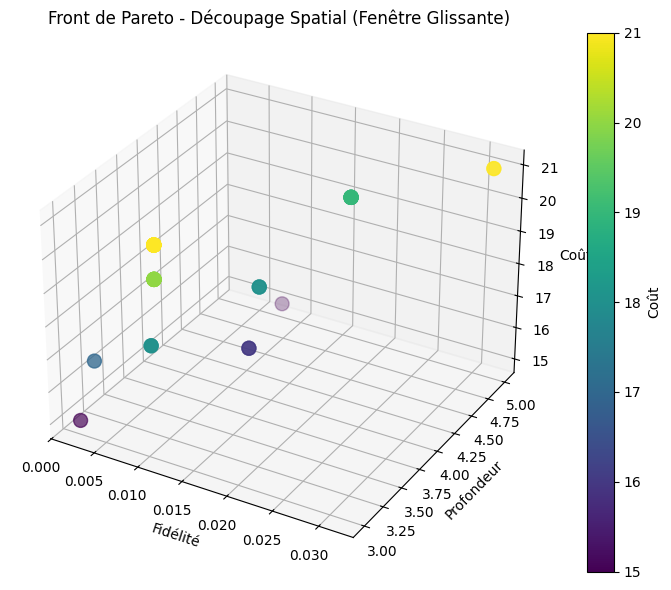

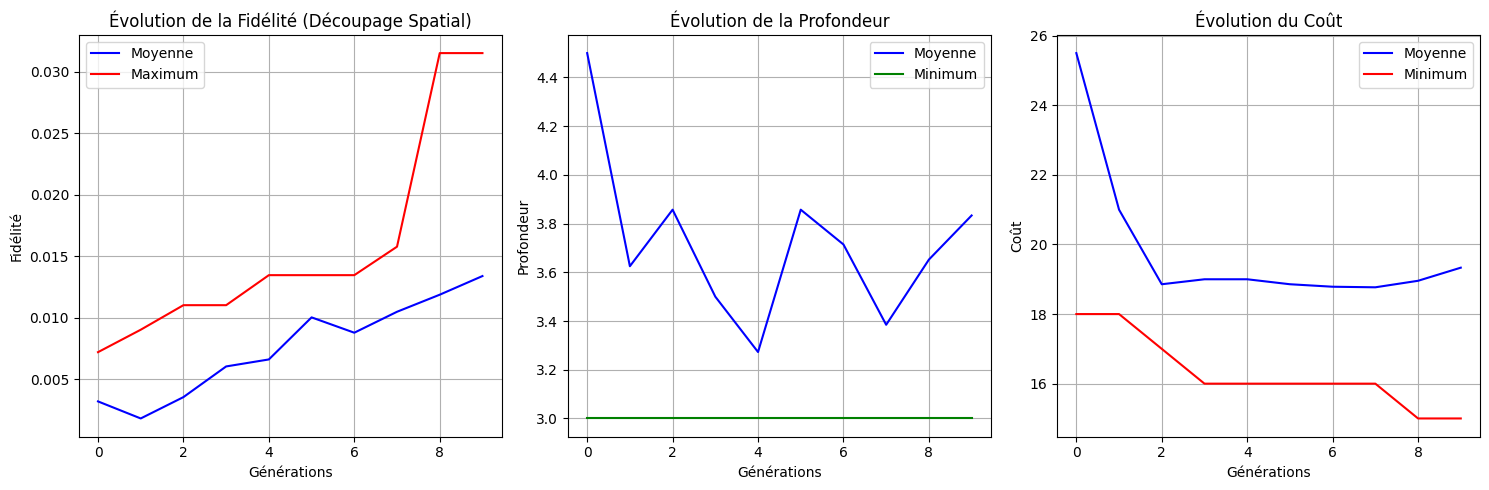


🏆 Meilleur circuit (fidélité) après ajustement:
Fidélité approx: 0.0315
Fidélité exacte:  0.0315
Profondeur: 5
Coût: 21
Circuit Optimisé:


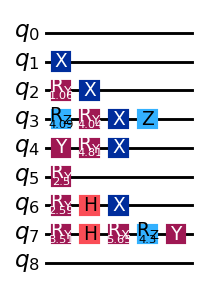


📈 Analyse du découpage spatial:
Solutions avant ajustement: 48
Solutions après ajustement: 48
Fidélité moyenne originale: 0.0129
Fidélité moyenne ajustée:   0.0129
Amélioration moyenne: 0.0000

✅ Avantages du découpage spatial:
  - Blocs cohérents par groupes de qubits
  - Distribution équilibrée de la charge
  - Respect de la topologie quantique
  - Fenêtre glissante avec chevauchement contrôlé


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator
from joblib import Parallel, delayed
import copy
from mpl_toolkits.mplot3d import Axes3D

# -------------------- Coûts des portes --------------------
GATE_COSTS = {
    'NOT': 1,
    'Phase': 1,
    'H': 2,      # Hadamard
    'X': 1,
    'Y': 1,
    'Z': 1,
    'CNOT': 5,
    'CX': 5,     # Équivalent à CNOT
    'SWAP': 11,
    'Peres': 12,
    'Toffoli': 13,
    'Fredkin': 19,
    'Miller': 24,
    'RX': 1,     # Rotation gates
    'RY': 1,
    'RZ': 1
}

# -------------------- Paramètres de fenêtre glissante --------------------
BLOCK_SIZE = 3  # Taille de chaque bloc (nombre de qubits)
OVERLAP_SIZE = 0 # Chevauchement entre blocs (nombre de qubits)
VALIDITY_THRESHOLD = 0.05  # Seuil pour test de validité
MAX_ADJUSTMENT_ATTEMPTS = 10  # Nombre max de tentatives d'ajustement

# -------------------- Classe pour l'individu multi-objectifs --------------------
class MultiObjectiveIndividual:
    def __init__(self, chromosome, fitness_values=None):
        self.chromosome = chromosome
        self.fitness_values = fitness_values  # [fidelity, -depth, -cost]
        self.rank = None
        self.crowding_distance = 0
        self.dominated_by = []
        self.dominates = []

    def dominates_other(self, other):
        """Vérifie si cet individu domine un autre (tous objectifs >= et au moins un >)"""
        if self.fitness_values is None or other.fitness_values is None:
            return False

        better_in_all = all(self.fitness_values[i] >= other.fitness_values[i] for i in range(len(self.fitness_values)))
        better_in_at_least_one = any(self.fitness_values[i] > other.fitness_values[i] for i in range(len(self.fitness_values)))

        return better_in_all and better_in_at_least_one

# -------------------- Génération des circuits --------------------
def generate_gene(num_qubits):
    """Génère un gène aléatoire représentant une porte quantique."""
    quantum_gates = {
        "H": {"control": False, "rotation": False},
        "X": {"control": False, "rotation": False},
        "Y": {"control": False, "rotation": False},
        "Z": {"control": False, "rotation": False},
        "CX": {"control": True, "rotation": False},
        "RX": {"control": False, "rotation": True},
        "RY": {"control": False, "rotation": True},
        "RZ": {"control": False, "rotation": True}
    }

    target_qubit = np.random.randint(num_qubits)
    gate = np.random.choice(list(quantum_gates.keys()))
    control_qubit = None
    angle = None

    if quantum_gates[gate]["control"]:
        control_qubit = np.random.randint(num_qubits)
        while control_qubit == target_qubit:
            control_qubit = np.random.randint(num_qubits)

    if quantum_gates[gate]["rotation"]:
        angle = np.random.uniform(0, 2 * np.pi)

    return [target_qubit, gate, control_qubit, angle]

def generate_chromosome(num_qubits, num_genes):
    """Génère un chromosome (séquence de gènes)."""
    return [generate_gene(num_qubits) for _ in range(num_genes)]

def generate_population(pop_size, num_qubits, num_genes):
    """Génère une population de chromosomes."""
    return [generate_chromosome(num_qubits, num_genes) for _ in range(pop_size)]

def create_quantum_circuit(chromosome, num_qubits):
    """Transforme un chromosome en circuit quantique Qiskit."""
    circuit = QuantumCircuit(num_qubits)

    for gene in chromosome:
        target, gate, control, angle = gene

        if gate in ["H", "X", "Y", "Z"]:
            getattr(circuit, gate.lower())(target)
        elif gate == "CX":
            circuit.cx(control, target)
        elif gate in ["RX", "RY", "RZ"]:
            getattr(circuit, gate.lower())(angle, target)

    return circuit

# -------------------- Fonction helper pour obtenir l'index d'un qubit --------------------
def get_qubit_index(qubit):
    """Obtient l'index d'un qubit de manière compatible avec toutes les versions de Qiskit."""
    if hasattr(qubit, 'index'):
        return qubit.index
    elif hasattr(qubit, '_index'):
        return qubit._index
    else:
        # Fallback: extraire l'index depuis la représentation string
        return int(str(qubit).split('[')[1].split(']')[0])

def create_circuit_blocks_spatial(circuit, block_size=BLOCK_SIZE, overlap=OVERLAP_SIZE):
    """
    Découpe un circuit en blocs spatiaux avec fenêtre glissante sur les qubits.

    Paramètres:
    - circuit: Circuit Qiskit à découper
    - block_size: Nombre de qubits par bloc
    - overlap: Nombre de qubits de chevauchement entre blocs

    Retourne: Liste de circuits de blocs
    """
    if circuit.size() == 0 or circuit.num_qubits == 0:
        return []

    num_qubits = circuit.num_qubits
    blocks = []

    # Calculer les positions de début de chaque bloc
    block_starts = []
    i = 0
    while i < num_qubits:
        block_starts.append(i)
        step = block_size - overlap
        if step <= 0:
            step = 1  # Éviter boucle infinie
        i += step
        if i >= num_qubits and len(block_starts) == 1:
            break  # Au moins un bloc couvre tout

    for block_idx, start_qubit in enumerate(block_starts):
        end_qubit = min(start_qubit + block_size, num_qubits)
        target_qubits = set(range(start_qubit, end_qubit))
        actual_block_size = len(target_qubits)

        # Créer un circuit pour ce bloc
        block_circuit = QuantumCircuit(actual_block_size)
        relevant_gates = 0

        # Créer le mapping global → local
        qubit_mapping = {global_q: local_q for local_q, global_q in enumerate(sorted(target_qubits))}

        # Parcourir toutes les instructions du circuit original
        for instruction in circuit.data:
            # Obtenir les qubits concernés par cette instruction en utilisant la fonction helper
            instruction_qubits = {get_qubit_index(qubit) for qubit in instruction.qubits}

            # Vérifier si tous les qubits de l'instruction sont dans ce bloc
            if instruction_qubits.issubset(target_qubits):
                # Remapper les indices des qubits vers les indices locaux
                local_qubits = [qubit_mapping[get_qubit_index(qubit)] for qubit in instruction.qubits]

                try:
                    if len(local_qubits) == 1:
                        # Porte à 1 qubit - passer l'index directement
                        block_circuit.append(instruction.operation, [local_qubits[0]])
                    elif len(local_qubits) == 2:
                        # Porte à 2 qubits - passer la liste
                        block_circuit.append(instruction.operation, local_qubits)
                    else:
                        # Portes à plus de 2 qubits (rare) - passer la liste
                        block_circuit.append(instruction.operation, local_qubits)

                    relevant_gates += 1

                except Exception as e:
                    continue

        blocks.append(block_circuit)

    return blocks

def create_target_blocks(target_circuit, block_size=BLOCK_SIZE, overlap=OVERLAP_SIZE):
    """Divise le circuit cible en blocs spatiaux correspondants."""
    return create_circuit_blocks_spatial(target_circuit, block_size, overlap)

def compute_trace_overlap(unitary1, unitary2):
    """Calcule le trace overlap entre deux matrices unitaires."""
    if unitary1.shape != unitary2.shape:
        return 0.0

    trace_value = np.trace(np.dot(unitary1, np.conj(unitary2.T)))
    dimension = unitary1.shape[0]
    return np.abs(trace_value) / dimension

def evaluate_block_fitness(candidate_block, target_block):
    """Évalue la fitness d'un bloc candidat vs bloc cible."""
    try:
        # Cas spécial: blocs vides
        if candidate_block.size() == 0 and target_block.size() == 0:
            return 1.0  # Identité vs identité = parfait

        if candidate_block.size() == 0:
            # Bloc candidat vide = identité
            identity = np.eye(2**candidate_block.num_qubits, dtype=complex)
            target_unitary = Operator(target_block).to_matrix()
            return compute_trace_overlap(identity, target_unitary)

        if target_block.size() == 0:
            # Bloc cible vide = identité
            candidate_unitary = Operator(candidate_block).to_matrix()
            identity = np.eye(2**target_block.num_qubits, dtype=complex)
            return compute_trace_overlap(candidate_unitary, identity)

        # Cas normal: les deux ont des portes
        candidate_unitary = Operator(candidate_block).to_matrix()
        target_unitary = Operator(target_block).to_matrix()

        return compute_trace_overlap(candidate_unitary, target_unitary)

    except Exception as e:
        # print(f"⚠️ Erreur évaluation bloc: {e}")
        return 0.0

# -------------------- Évaluation par fenêtre glissante spatiale --------------------
def compute_sliding_window_fidelity(chromosome, num_qubits, target_circuit):
    """Calcule la fidélité using sliding window spatial approach."""
    if len(chromosome) == 0:
        return 0.0

    # Créer le circuit candidat à partir du chromosome
    candidate_circuit = create_quantum_circuit(chromosome, num_qubits)

    if candidate_circuit.size() == 0:
        return 0.0

    # Diviser les deux circuits en blocs spatiaux
    candidate_blocks = create_circuit_blocks_spatial(candidate_circuit)
    target_blocks = create_target_blocks(target_circuit)

    # Assurer qu'on a des blocs à comparer
    min_blocks = min(len(candidate_blocks), len(target_blocks))
    if min_blocks == 0:
        return 0.0

    # Évaluer chaque paire de blocs
    block_fitnesses = []
    for i in range(min_blocks):
        try:
            fitness = evaluate_block_fitness(candidate_blocks[i], target_blocks[i])
            block_fitnesses.append(fitness)
        except Exception as e:
            # print(f"⚠️ Erreur bloc {i}: {e}")
            block_fitnesses.append(0.0)

    if len(block_fitnesses) == 0:
        return 0.0

    # Combiner les fitness des blocs (produit géométrique)
    product_fitness = 1.0
    for fitness in block_fitnesses:
        product_fitness *= max(fitness, 1e-10)  # Éviter les zéros

    # Racine n-ième pour normaliser
    final_fitness = product_fitness

    return final_fitness

def compute_exact_fidelity(circuit, target_unitary):
    """Calcule la fidélité exacte (méthode originale)."""
    candidate_unitary = Operator(circuit).data
    target_dagger = np.conj(target_unitary.T)
    trace_value = np.trace(np.dot(candidate_unitary, target_dagger))
    num_qubits = circuit.num_qubits
    return np.abs(trace_value) / (2 ** num_qubits)

def compute_circuit_depth(circuit):
    """Calcule la profondeur du circuit."""
    return circuit.depth()

def compute_circuit_cost(chromosome):
    """Calcule le coût total du circuit basé sur les portes utilisées."""
    total_cost = 0
    for gene in chromosome:
        gate = gene[1]
        if gate in GATE_COSTS:
            total_cost += GATE_COSTS[gate]
        else:
            total_cost += 1  # Coût par défaut
    return total_cost

# -------------------- Ajustements automatiques --------------------
def adjust_gate_angles(chromosome, num_qubits, target_circuit, adjustment_factor=0.1):
    """Ajuste les angles des portes de rotation."""
    adjusted = copy.deepcopy(chromosome)

    for gene in adjusted:
        if len(gene) >= 4 and gene[3] is not None:  # Porte de rotation
            # Petite perturbation aléatoire
            perturbation = np.random.uniform(-adjustment_factor, adjustment_factor) * np.pi
            gene[3] = (gene[3] + perturbation) % (2 * np.pi)

    return adjusted

def add_correction_gates(chromosome, num_qubits, max_additions=2):
    """Ajoute quelques portes correctives."""
    adjusted = copy.deepcopy(chromosome)

    for _ in range(np.random.randint(1, max_additions + 1)):
        new_gene = generate_gene(num_qubits)
        position = np.random.randint(len(adjusted) + 1)
        adjusted.insert(position, new_gene)

    return adjusted

def remove_redundant_gates(chromosome, num_qubits, target_circuit):
    """Supprime des portes qui dégradent la performance."""
    if len(chromosome) <= 1:
        return chromosome

    best_fitness = compute_sliding_window_fidelity(chromosome, num_qubits, target_circuit)
    adjusted = copy.deepcopy(chromosome)

    # Essayer de supprimer chaque porte
    for i in range(len(chromosome)):
        temp_chromo = copy.deepcopy(chromosome)
        del temp_chromo[i]

        if len(temp_chromo) > 0:
            temp_fitness = compute_sliding_window_fidelity(temp_chromo, num_qubits, target_circuit)
            if temp_fitness > best_fitness:
                adjusted = temp_chromo
                best_fitness = temp_fitness
                break

    return adjusted

def auto_adjust_circuit(chromosome, num_qubits, target_circuit, max_attempts=MAX_ADJUSTMENT_ATTEMPTS):
    """Ajustement automatique du circuit pour améliorer la fitness."""
    print(f"🔧 Ajustement automatique du circuit...")

    original_fitness = compute_sliding_window_fidelity(chromosome, num_qubits, target_circuit)
    best_chromosome = copy.deepcopy(chromosome)
    best_fitness = original_fitness

    for attempt in range(max_attempts):
        # Essayer différentes stratégies d'ajustement
        strategies = [
            lambda c: adjust_gate_angles(c, num_qubits, target_circuit),
            lambda c: add_correction_gates(c, num_qubits),
            lambda c: remove_redundant_gates(c, num_qubits, target_circuit)
        ]

        strategy = np.random.choice(strategies)
        adjusted_chromosome = strategy(copy.deepcopy(best_chromosome))

        adjusted_fitness = compute_sliding_window_fidelity(adjusted_chromosome, num_qubits, target_circuit)

        if adjusted_fitness > best_fitness:
            best_chromosome = adjusted_chromosome
            best_fitness = adjusted_fitness
            print(f"  Amélioration trouvée (tentative {attempt+1}): {best_fitness:.4f}")

    improvement = best_fitness - original_fitness
    print(f"  Amélioration totale: {improvement:.4f}")

    return best_chromosome

# -------------------- Évaluation avec validation --------------------
def evaluate_individual(chromosome, num_qubits, target_circuit):
    """Évalue un individu sur les trois objectifs avec validation."""
    if len(chromosome) == 0:
        return [0.0, 0.0, 0.0]

    circuit = create_quantum_circuit(chromosome, num_qubits)

    # Objectif 1: Fidélité approximative (fenêtre glissante spatiale)
    approx_fidelity = compute_sliding_window_fidelity(chromosome, num_qubits, target_circuit)

    # Objectif 2: Profondeur (à minimiser -> on prend le négatif)
    depth = compute_circuit_depth(circuit)

    # Objectif 3: Coût (à minimiser -> on prend le négatif)
    cost = compute_circuit_cost(chromosome)

    # Retourne [fidelity, -depth, -cost] pour maximiser tous les objectifs
    return [approx_fidelity, -depth, -cost]

def validate_and_adjust_best_solutions(pareto_front, num_qubits, target_circuit):
    """Valide et ajuste les meilleures solutions du front de Pareto."""
    print(f"\n🔍 Validation et ajustement des solutions...")

    adjusted_solutions = []
    target_unitary = Operator(target_circuit).to_matrix()

    for i, individual in enumerate(pareto_front):
        # Calculer fitness approximative vs exacte
        circuit = create_quantum_circuit(individual.chromosome, num_qubits)
        approx_fidelity = individual.fitness_values[0]
        exact_fidelity = compute_exact_fidelity(circuit, target_unitary)

        error = abs(approx_fidelity - exact_fidelity)

        print(f"Solution {i+1}: Approx={approx_fidelity:.4f}, Exact={exact_fidelity:.4f}, Erreur={error:.4f}")

        # Si l'erreur est trop grande, ajuster
        if error > VALIDITY_THRESHOLD:
            print(f"  ⚠️ Erreur > seuil ({VALIDITY_THRESHOLD}), ajustement nécessaire")
            adjusted_chromosome = auto_adjust_circuit(individual.chromosome, num_qubits, target_circuit)

            # Réévaluer
            adjusted_fitness = evaluate_individual(adjusted_chromosome, num_qubits, target_circuit)
            adjusted_individual = MultiObjectiveIndividual(adjusted_chromosome, adjusted_fitness)
            adjusted_solutions.append(adjusted_individual)

            # Vérifier l'amélioration
            final_exact = compute_exact_fidelity(create_quantum_circuit(adjusted_chromosome, num_qubits), target_unitary)
            print(f"  ✅ Après ajustement: Exact={final_exact:.4f}")
        else:
            print(f"  ✅ Erreur acceptable")
            adjusted_solutions.append(individual)

    return adjusted_solutions

def parallel_evaluation(population, num_qubits, target_circuit):
    """Évaluation parallèle de la population."""
    return Parallel(n_jobs=-1)(
        delayed(evaluate_individual)(chromo, num_qubits, target_circuit)
        for chromo in population
    )

# -------------------- NSGA-II Implementation --------------------
def fast_non_dominated_sort(population):
    """Tri rapide non-dominé (NSGA-II)."""
    fronts = [[]]

    for i, ind_i in enumerate(population):
        ind_i.dominated_by = []
        ind_i.dominates = []

        for j, ind_j in enumerate(population):
            if i != j:
                if ind_i.dominates_other(ind_j):
                    ind_i.dominates.append(j)
                elif ind_j.dominates_other(ind_i):
                    ind_i.dominated_by.append(j)

        if len(ind_i.dominated_by) == 0:
            ind_i.rank = 0
            fronts[0].append(i)

    i = 0
    while len(fronts[i]) > 0:
        next_front = []
        for p in fronts[i]:
            for q in population[p].dominates:
                population[q].dominated_by.remove(p)
                if len(population[q].dominated_by) == 0:
                    population[q].rank = i + 1
                    next_front.append(q)
        i += 1
        fronts.append(next_front)

    return fronts[:-1]  # Enlever le dernier front vide

def calculate_crowding_distance(population, front):
    """Calcule la distance de crowding pour un front donné."""
    if len(front) <= 2:
        for i in front:
            population[i].crowding_distance = float('inf')
        return

    # Initialiser les distances
    for i in front:
        population[i].crowding_distance = 0

    # Pour chaque objectif
    num_objectives = len(population[front[0]].fitness_values)
    for obj in range(num_objectives):
        # Trier par objectif
        front.sort(key=lambda x: population[x].fitness_values[obj])

        # Assigner distance infinie aux extrêmes
        population[front[0]].crowding_distance = float('inf')
        population[front[-1]].crowding_distance = float('inf')

        # Calculer pour les autres
        if len(front) > 2:
            obj_range = population[front[-1]].fitness_values[obj] - population[front[0]].fitness_values[obj]
            if obj_range > 0:
                for i in range(1, len(front) - 1):
                    distance = (population[front[i + 1]].fitness_values[obj] -
                              population[front[i - 1]].fitness_values[obj]) / obj_range
                    population[front[i]].crowding_distance += distance

def nsga2_selection(population, pop_size):
    """Sélection NSGA-II."""
    fronts = fast_non_dominated_sort(population)

    new_population = []
    for front in fronts:
        calculate_crowding_distance(population, front)

        if len(new_population) + len(front) <= pop_size:
            new_population.extend([population[i] for i in front])
        else:
            # Trier par distance de crowding décroissante
            front.sort(key=lambda x: population[x].crowding_distance, reverse=True)
            remaining = pop_size - len(new_population)
            new_population.extend([population[i] for i in front[:remaining]])
            break

    return new_population

# -------------------- Opérateurs génétiques --------------------
def crossover(parent1, parent2):
    """Croisement entre deux parents."""
    min_length = min(len(parent1), len(parent2))
    if min_length < 2:
        return parent1.copy(), parent2.copy()

    cut_point = np.random.randint(1, min_length)
    child1 = parent1[:cut_point] + parent2[cut_point:]
    child2 = parent2[:cut_point] + parent1[cut_point:]

    return child1, child2

def mutate(chromosome, num_qubits, mutation_rate=0.1):
    """Mutation d'un chromosome."""
    if np.random.rand() < mutation_rate:
        # Mutation de gène
        if len(chromosome) > 0:
            idx = np.random.randint(len(chromosome))
            chromosome[idx] = generate_gene(num_qubits)

    # Mutation structurelle
    if np.random.rand() < 0.1:
        if np.random.rand() < 0.5 and len(chromosome) > 1:
            # Supprimer un gène
            idx = np.random.randint(len(chromosome))
            del chromosome[idx]
        else:
            # Ajouter un gène
            new_gene = generate_gene(num_qubits)
            idx = np.random.randint(len(chromosome) + 1)
            chromosome.insert(idx, new_gene)

    return chromosome

def tournament_selection(population, tournament_size=3):
    """Sélection par tournoi pour le croisement."""
    tournament = np.random.choice(population, tournament_size, replace=False)

    # Choisir le meilleur selon le rang et la distance de crowding
    best = tournament[0]
    for individual in tournament[1:]:
        if (individual.rank < best.rank or
            (individual.rank == best.rank and individual.crowding_distance > best.crowding_distance)):
            best = individual

    return best

# -------------------- Algorithme génétique multi-objectifs --------------------
def multi_objective_genetic_algorithm(num_qubits, num_genes, pop_size, generations, target_circuit,
                                    mutation_rate=0.1, crossover_rate=0.9):
    """Algorithme génétique multi-objectifs principal."""

    # Initialiser la population
    chromosomes = generate_population(pop_size, num_qubits, num_genes)
    fitness_values = parallel_evaluation(chromosomes, num_qubits, target_circuit)

    population = [MultiObjectiveIndividual(chromo, fitness)
                  for chromo, fitness in zip(chromosomes, fitness_values)]

    # Historique des fronts de Pareto
    pareto_history = []

    for generation in range(generations):
        print(f"\nGénération {generation + 1}/{generations}")

        # Sélection NSGA-II
        fronts = fast_non_dominated_sort(population)

        # Sauvegarder le front de Pareto
        if len(fronts) > 0:
            pareto_front = [population[i] for i in fronts[0]]
            pareto_history.append(pareto_front)

            # Afficher statistiques
            fidelities = [ind.fitness_values[0] for ind in pareto_front]
            depths = [-ind.fitness_values[1] for ind in pareto_front]
            costs = [-ind.fitness_values[2] for ind in pareto_front]

            print(f"Front de Pareto: {len(pareto_front)} solutions")
            print(f"Fidélité: {np.mean(fidelities):.4f} ± {np.std(fidelities):.4f}")
            print(f"Profondeur: {np.mean(depths):.2f} ± {np.std(depths):.2f}")
            print(f"Coût: {np.mean(costs):.2f} ± {np.std(costs):.2f}")

        # Créer la nouvelle génération
        offspring = []

        while len(offspring) < pop_size:
            # Sélection des parents
            parent1 = tournament_selection(population)
            parent2 = tournament_selection(population)

            # Croisement
            if np.random.rand() < crossover_rate:
                child1_chromo, child2_chromo = crossover(parent1.chromosome, parent2.chromosome)
            else:
                child1_chromo, child2_chromo = parent1.chromosome.copy(), parent2.chromosome.copy()

            # Mutation
            child1_chromo = mutate(child1_chromo, num_qubits, mutation_rate)
            child2_chromo = mutate(child2_chromo, num_qubits, mutation_rate)

            # Évaluation
            child1_fitness = evaluate_individual(child1_chromo, num_qubits, target_circuit)
            child2_fitness = evaluate_individual(child2_chromo, num_qubits, target_circuit)

            offspring.append(MultiObjectiveIndividual(child1_chromo, child1_fitness))
            if len(offspring) < pop_size:
                offspring.append(MultiObjectiveIndividual(child2_chromo, child2_fitness))

        # Fusion parents + offspring
        combined_population = population + offspring

        # Sélection NSGA-II
        population = nsga2_selection(combined_population, pop_size)

    # Retourner le front de Pareto final
    final_fronts = fast_non_dominated_sort(population)
    final_pareto_front = [population[i] for i in final_fronts[0]]

    return final_pareto_front, pareto_history

# -------------------- Visualisation --------------------
def plot_pareto_front_3d(pareto_front):
    """Visualise le front de Pareto en 3D."""
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    fidelities = [ind.fitness_values[0] for ind in pareto_front]
    depths = [-ind.fitness_values[1] for ind in pareto_front]
    costs = [-ind.fitness_values[2] for ind in pareto_front]

    scatter = ax.scatter(fidelities, depths, costs, c=costs, cmap='viridis', s=100)

    ax.set_xlabel('Fidélité')
    ax.set_ylabel('Profondeur')
    ax.set_zlabel('Coût')
    ax.set_title('Front de Pareto - Découpage Spatial (Fenêtre Glissante)')

    plt.colorbar(scatter, label='Coût')
    plt.tight_layout()
    plt.show()

def plot_pareto_evolution(pareto_history):
    """Visualise l'évolution du front de Pareto."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    generations = range(len(pareto_history))

    # Évolution de la fidélité
    avg_fidelities = [np.mean([ind.fitness_values[0] for ind in front]) for front in pareto_history]
    max_fidelities = [np.max([ind.fitness_values[0] for ind in front]) for front in pareto_history]

    axes[0].plot(generations, avg_fidelities, 'b-', label='Moyenne')
    axes[0].plot(generations, max_fidelities, 'r-', label='Maximum')
    axes[0].set_xlabel('Générations')
    axes[0].set_ylabel('Fidélité')
    axes[0].set_title('Évolution de la Fidélité (Découpage Spatial)')
    axes[0].legend()
    axes[0].grid(True)

    # Évolution de la profondeur
    avg_depths = [np.mean([-ind.fitness_values[1] for ind in front]) for front in pareto_history]
    min_depths = [np.min([-ind.fitness_values[1] for ind in front]) for front in pareto_history]

    axes[1].plot(generations, avg_depths, 'b-', label='Moyenne')
    axes[1].plot(generations, min_depths, 'g-', label='Minimum')
    axes[1].set_xlabel('Générations')
    axes[1].set_ylabel('Profondeur')
    axes[1].set_title('Évolution de la Profondeur')
    axes[1].legend()
    axes[1].grid(True)

    # Évolution du coût
    avg_costs = [np.mean([-ind.fitness_values[2] for ind in front]) for front in pareto_history]
    min_costs = [np.min([-ind.fitness_values[2] for ind in front]) for front in pareto_history]

    axes[2].plot(generations, avg_costs, 'b-', label='Moyenne')
    axes[2].plot(generations, min_costs, 'r-', label='Minimum')
    axes[2].set_xlabel('Générations')
    axes[2].set_ylabel('Coût')
    axes[2].set_title('Évolution du Coût')
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

# -------------------- Circuit de test --------------------
def create_target_circuit(num_qubits=6, num_layers=2):
    """Crée un circuit cible pour les tests."""
    circuit = QuantumCircuit(9)
    for i in range(9):
        circuit.h(i)

    for layer in range(num_layers):
        for j in range(2):           # 0,1,2 -> cx(0,1),cx(1,2),cx(2,3)
            circuit.cx(j, j + 1)
    for layer in range(num_layers):
        for j in range(3,5):         # 3,4,5 -> cx(3,4),cx(4,5),cx(5,6)
            circuit.cx(j, j + 1)
    for layer in range(num_layers):
        for j in range(6,8):         # <-- ici j va de 6 à 7, pas jusqu'à 8
            circuit.cx(j, j + 1)

    for i in range(9):
        circuit.rz((i + 1) * np.pi / 14, i)

    print("🎯 Circuit Cible:")
    fig, ax = plt.subplots(figsize=(6, 3))  # Un seul subplot, taille ajustée
    circuit.draw(output='mpl', ax=ax, fold=20)
    plt.tight_layout()
    plt.show()

    return circuit

# -------------------- Exécution principal --------------------
if __name__ == "__main__":
    # Paramètres
    num_qubits = 9
    num_genes = 18
    pop_size = 50
    generations = 10

    print(f"🔧 Paramètres de la fenêtre glissante SPATIALE:")
    print(f"  - Taille des blocs: {BLOCK_SIZE} qubits")
    print(f"  - Chevauchement: {OVERLAP_SIZE} qubits")
    print(f"  - Seuil de validité: {VALIDITY_THRESHOLD}")
    print(f"  - Max ajustements: {MAX_ADJUSTMENT_ATTEMPTS}")

    # Créer le circuit cible
    target_circuit = create_target_circuit(num_qubits)

    print("\n🚀 Démarrage de l'optimisation multi-objectifs avec découpage spatial...")
    print(f"Paramètres: {num_qubits} qubits, {num_genes} gènes, {pop_size} individus, {generations} générations")

    # Exécuter l'algorithme
    pareto_front, pareto_history = multi_objective_genetic_algorithm(
        num_qubits, num_genes, pop_size, generations, target_circuit,
        mutation_rate=0.1, crossover_rate=0.9
    )

    print(f"\n🎯 Optimisation terminée!")
    print(f"Front de Pareto initial: {len(pareto_front)} solutions")

    # Validation et ajustement des meilleures solutions
    #adjusted_pareto_front = validate_and_adjust_best_solutions(pareto_front, num_qubits, target_circuit)
    adjusted_pareto_front = pareto_front

    print(f"\n📊 Top 5 solutions ajustées du front de Pareto:")
    target_unitary = Operator(target_circuit).to_matrix()

    for i, ind in enumerate(adjusted_pareto_front[:5]):
        fidelity = ind.fitness_values[0]
        depth = -ind.fitness_values[1]
        cost = -ind.fitness_values[2]
        circuit = create_quantum_circuit(ind.chromosome, num_qubits)
        exact_fidelity = compute_exact_fidelity(circuit, target_unitary)

        print(f"Solution {i+1}:")
        print(f"  Fidélité approx: {fidelity:.4f}")
        print(f"  Fidélité exacte:  {exact_fidelity:.4f}")
        print(f"  Profondeur: {depth:.0f}")
        print(f"  Coût: {cost:.0f}")
        print(f"  Circuit: {len(ind.chromosome)} portes")
        print()

    # Visualisations
    plot_pareto_front_3d(adjusted_pareto_front)
    plot_pareto_evolution(pareto_history)

    # Afficher le meilleur circuit
    best_fidelity_ind = max(adjusted_pareto_front, key=lambda x: x.fitness_values[0])
    best_circuit = create_quantum_circuit(best_fidelity_ind.chromosome, num_qubits)
    exact_fidelity = compute_exact_fidelity(best_circuit, target_unitary)

    print(f"\n🏆 Meilleur circuit (fidélité) après ajustement:")
    print(f"Fidélité approx: {best_fidelity_ind.fitness_values[0]:.4f}")
    print(f"Fidélité exacte:  {exact_fidelity:.4f}")
    print(f"Profondeur: {-best_fidelity_ind.fitness_values[1]:.0f}")
    print(f"Coût: {-best_fidelity_ind.fitness_values[2]:.0f}")
    print("Circuit Optimisé:")
    fig, ax = plt.subplots(figsize=(6, 3))
    best_circuit.draw(output='mpl', ax=ax, fold=20)
    plt.tight_layout()
    plt.show()

    # Analyse comparative
    print(f"\n📈 Analyse du découpage spatial:")
    print(f"Solutions avant ajustement: {len(pareto_front)}")
    print(f"Solutions après ajustement: {len(adjusted_pareto_front)}")

    # Comparer les fidélités moyennes
    original_fidelities = [ind.fitness_values[0] for ind in pareto_front]
    adjusted_fidelities = [ind.fitness_values[0] for ind in adjusted_pareto_front]

    print(f"Fidélité moyenne originale: {np.mean(original_fidelities):.4f}")
    print(f"Fidélité moyenne ajustée:   {np.mean(adjusted_fidelities):.4f}")
    print(f"Amélioration moyenne: {np.mean(adjusted_fidelities) - np.mean(original_fidelities):.4f}")

    print(f"\n✅ Avantages du découpage spatial:")
    print(f"  - Blocs cohérents par groupes de qubits")
    print(f"  - Distribution équilibrée de la charge")
    print(f"  - Respect de la topologie quantique")
    print(f"  - Fenêtre glissante avec chevauchement contrôlé")